In [1]:
%load_ext autoreload
%autoreload 2

import uproot
import awkward as ak

import matplotlib.pylab as plt
import numpy as np

import time

from hist import Hist

import babar_analysis_tools as bat

from analysis_variables import *

import myPIDselector

import pandas as pd
import seaborn as sns

import joblib

# References

## BaBar

https://babar-wiki.heprc.uvic.ca/bbr_wiki/index.php/Find_Data

https://babar-wiki.heprc.uvic.ca/bbr_wiki/index.php/Physics

https://babar-wiki.heprc.uvic.ca/bbr_wiki/index.php/Physics/skims

https://babar-wiki.heprc.uvic.ca/bbr_wiki/index.php/Available_Data

https://babar-wiki.heprc.uvic.ca/bbr_wiki/index.php/Available_Lists#Composite_Particle_Lists

https://babar-wiki.heprc.uvic.ca/bbr_wiki/index.php/Lambda_Lists

## Physics

https://pdglive.lbl.gov/Viewer.action

https://pdglive.lbl.gov/ParticleGroup.action?init=0&node=BXXX020

https://pdglive.lbl.gov/Particle.action?init=0&node=S033&home=BXXX040

https://pdglive.lbl.gov/ParticleGroup.action?init=0&node=MXXX045



## Code

### Uproot
https://uproot.readthedocs.io/en/latest/basic.html

### Awkward arrays
https://awkward-array.org/doc/main/

https://awkward-array.org/doc/main/getting-started/index.html (see left-hand navigation bar with different tutorials)

### Histogram

https://hist.readthedocs.io/en/latest/




# Open the file and extract the data

Makes use of `parquet` files and `awkward` arrays. 

In [4]:
#####################################################################
# Where are we running this?
#####################################################################
## Bellis computer
#topdir= "/home/bellis/babar_data/bnv_analysis_lam0lam0"
topdir= "/home/bellis/babar_data_local/bnv_analysis_lam0lam0"

## Somewhere else?
#topdir= "/Users/josieswann/BaBar_analyses/BNV_pLambda/"
#####################################################################


#####################################################################
# Get the BNV data
#####################################################################
data, data_collision = bat.load_datasets(topdir=topdir, subset='all')


Opening /home/bellis/babar_data_local/bnv_analysis_lam0lam0/Background_and_signal_SP_modes_All_runs.parquet...
Took 0.623 seconds

Opening /home/bellis/babar_data_local/bnv_analysis_lam0lam0/Data_All_runs_BLINDED.parquet...
Took 0.191 seconds



In [5]:
# Display the variable names

keys = data.fields

keys

['runNumber',
 'platform',
 'partition',
 'upperID',
 'lowerID',
 'majorID',
 'configKey',
 'date',
 'ddate',
 'eePx',
 'eePy',
 'eePz',
 'eeE',
 'beamSX',
 'beamSY',
 'beamSZ',
 'beamSCovXX',
 'beamSCovYY',
 'beamSCovZZ',
 'beamSCovXZ',
 'nTracks',
 'nGoodTrkLoose',
 'nChargedTracks',
 'R2',
 'R2All',
 'thrustMag',
 'thrustMagAll',
 'thrustCosTh',
 'thrustCosThAll',
 'thrustPhi',
 'thrustPhiAll',
 'sphericityAll',
 'mcLen',
 'mcLund',
 'mothIdx',
 'dauLen',
 'dauIdx',
 'mcmass',
 'mcp3CM',
 'mccosthCM',
 'mcphiCM',
 'mcenergyCM',
 'mcp3',
 'mccosth',
 'mcphi',
 'mcenergy',
 'mcVtxx',
 'mcVtxy',
 'mcVtxz',
 'nB',
 'BChi2',
 'BCosSphr',
 'BCosThetaS',
 'BCosThetaT',
 'BCosThrust',
 'BLegendreP0',
 'BLegendreP2',
 'BMass',
 'BMassErr',
 'BPFlow0',
 'BPFlow1',
 'BPFlow2',
 'BPFlow3',
 'BPFlow4',
 'BPFlow5',
 'BPFlow6',
 'BPFlow7',
 'BPFlow8',
 'BR2ROE',
 'BSphr',
 'BSphrROE',
 'BThrust',
 'BThrustROE',
 'BVtxx',
 'BVtxy',
 'BVtxz',
 'B_con_Chi2',
 'B_con_Mass',
 'B_con_MassErr',
 'B_con_V

Print out the variables in the TTree/awkward array in a neater way. 

In [6]:
max_len = 80
output = ""
for k in keys:
    if len(output)<max_len:
        output = f"{output}{k:20s} "
    else:
        print(output)
        output = f"{k:20s} "

runNumber            platform             partition            upperID              
lowerID              majorID              configKey            date                 
ddate                eePx                 eePy                 eePz                 
eeE                  beamSX               beamSY               beamSZ               
beamSCovXX           beamSCovYY           beamSCovZZ           beamSCovXZ           
nTracks              nGoodTrkLoose        nChargedTracks       R2                   
R2All                thrustMag            thrustMagAll         thrustCosTh          
thrustCosThAll       thrustPhi            thrustPhiAll         sphericityAll        
mcLen                mcLund               mothIdx              dauLen               
dauIdx               mcmass               mcp3CM               mccosthCM            
mcphiCM              mcenergyCM           mcp3                 mccosth              
mcphi                mcenergy             mcVtxx               mc

# Exploring the data

In [10]:
# You can access the values in an TTree array as follow
# Note that in each case, we need the .array at the end to actually get the values. 

# Get the proton energy. 
x = data['penergy']

print(x)

# Get the number of protons in each event using an awkward function

n = ak.num(x)

print(n)

[[4.96, 1.42, 1.36], [2.59, 1.66], [1.89, ...], ..., [3.09, 2.13], [2.61, 2.52]]
[3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, ..., 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


# Interfacing with the files we will use for analysis

These files have already been processed and only the awkward arrays have been stored. 

These files are [parquet files](https://www.databricks.com/glossary/what-is-parquet).

## Some other examples

<Array [4.96, 1.42, 1.36, 2.59, ..., 2.13, 2.61, 2.52] type='207563 * float32'>

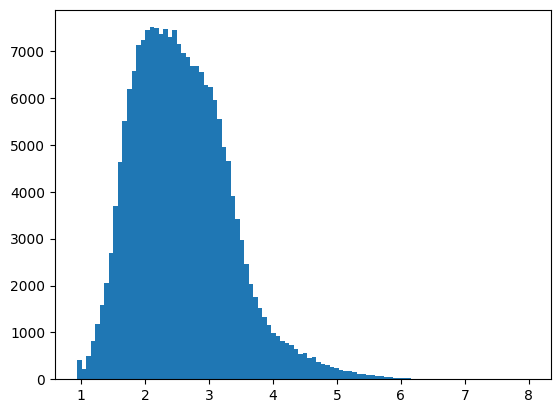

In [11]:
x = data['penergy']

# Need to flatten it before we plot, if it is multidimensional (if there are multiple events in each event)

x = ak.flatten(x)

plt.hist(x,bins=100);
x

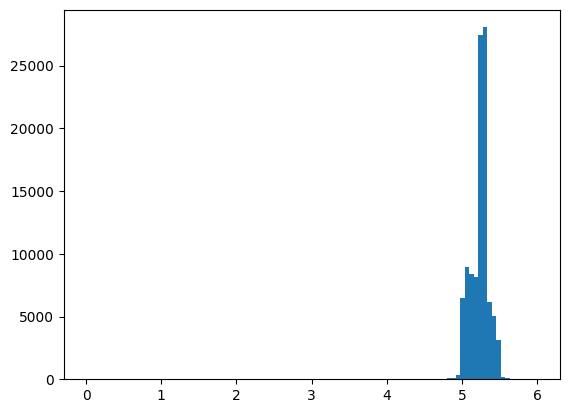

In [12]:
# Plot only the first instance in each event

x = data['BMass'][:,0]

# This is only 1-dimensional so we don't need to flatten it. 
plt.hist(x,bins=100, range=(0,6));

## Histogram

In [13]:
# Get all the SP modes

x = data['spmode']

spmodes = np.unique(x.to_list())

print(spmodes)

['-999' '1005' '1235' '1237' '3429' '998']


In [14]:
# Create a histogram
h = Hist.new.Reg(100, 5.2, 5.3, name="BpostFitMes", label=r"M$_{ES}$ [GeV/c$^2$]") \
         .StrCat([], name="SP", label="SP modes", growth=True)\
         .StrCat([], name="cuts", label="Cuts", growth=True)\
         .Weight()

# Fill the histogram
for spmode in spmodes:
    sp_mask = data.spmode == spmode
    x = data[sp_mask]['BpostFitMes'][:,0]
    h.fill(BpostFitMes=x, SP=spmode, cuts=f"0", weight=1)

Display it in different ways

In [15]:
#h[:,"998","0"].plot(histtype="fill", linewidth=1, edgecolor="grey")
#h[:,"-999","0"].plot(histtype="fill", linewidth=1, edgecolor="grey")

In [16]:
#h[:,"1235","0"].plot(histtype="fill", linewidth=1, edgecolor="grey")

In [17]:
#h.stack('SP')[:].project('BpostFitMes').plot(stack=True, histtype="fill")

#plt.legend()

Now for  the other thing!

In [18]:
# Create the histogram, this does not fill it in

j= Hist.new.Reg(100, -1,1, name= "BpostFitDeltaE", label= r"idk yet [GeV]?") \
        .StrCat([],name= "SP", label= "sp modes", growth= True)\
        .StrCat([], name= "cuts", label= "Cuts", growth= True)\
        .Weight()

# Fill 

for spmode in spmodes: 
    sp_mask2= data.spmode== spmode
    y= data[sp_mask2]["BpostFitDeltaE"][:,0]
    j.fill(BpostFitDeltaE=y, SP= spmode, cuts= f"0", weight=1)

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f2ca8268590>, errorbar=None, legend_artist=None)]

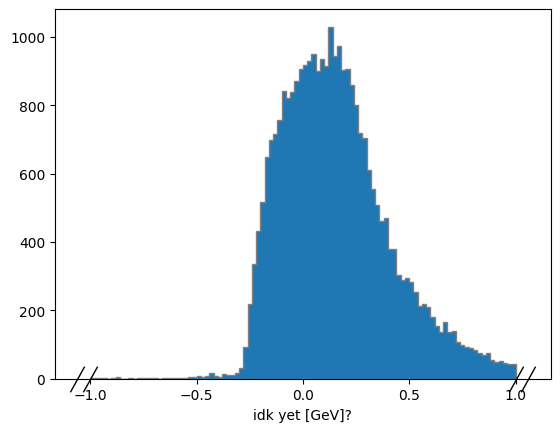

In [19]:
#j[:,"998","0"].plot(histtype="fill", linewidth=1, edgecolor="grey")
j[:,"998","0"].plot(histtype="fill", linewidth=1, edgecolor="grey")

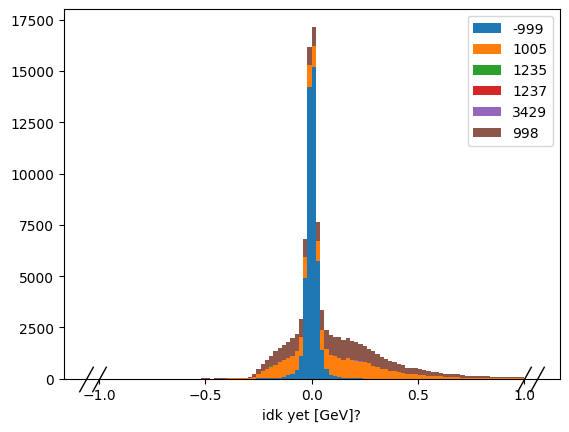

In [20]:
j.stack('SP')[:].project('BpostFitDeltaE').plot(stack=True, histtype="fill")

plt.legend()

## Lambda 


Matplotlib histogram:

In [21]:
Lambda_mass= data.Lambda0_unc_Mass
Flight_length= data.Lambda0FlightLen

flat_Lambda_mass= ak.flatten(Lambda_mass)

Flight_length

<Array [[0.00531, 0.198, 0.452], ..., [...]] type='103658 * var * float32'>

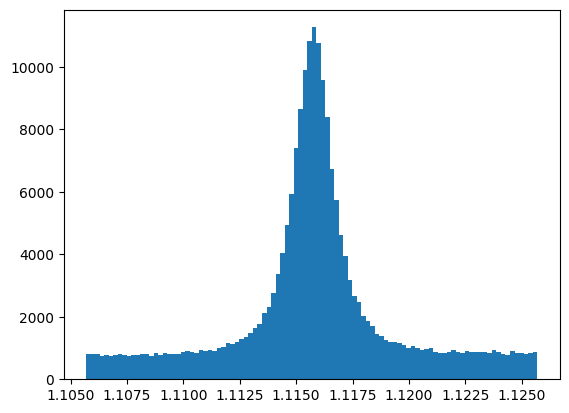

In [22]:
plt.hist(flat_Lambda_mass, bins= 100);

hist class:

In [23]:
h_lambda_FL= Hist.new.Reg(100, -.25,10, name= "Lambda0FlightLen", label= r"flight length [cm]") \
        .StrCat([],name= "SP", label= "sp modes", growth= True)\
        .StrCat([], name= "cuts", label= "Cuts", growth= True)\
        .Weight()

h_lambda_mass= Hist.new.Reg(100,1.105, 1.126, name= "Lambda0_unc_Mass", label= r"Mass GeV") \
        .StrCat([],name= "SP", label= "sp modes", growth= True)\
        .StrCat([], name= "cuts", label= "Cuts", growth= True)\
        .Weight()




for spmode in spmodes: 
    modes= data.spmode== spmode
    x0 = data[modes]["Lambda0FlightLen"][:,0]
    x1 = data[modes]["Lambda0_unc_Mass"][:,0]

    cut_name = "org"
    h_lambda_FL.fill(Lambda0FlightLen=x0,   SP= spmode, cuts= cut_name, weight=1)
    h_lambda_mass.fill(Lambda0_unc_Mass=x1, SP= spmode, cuts= cut_name, weight=1)

    # First cut
    cut_name = "fl_gt_val"
    flight_length_cutter = data[modes]["Lambda0FlightLen"][:,0] > 2.0

    h_lambda_FL.fill(Lambda0FlightLen=x0[flight_length_cutter],   SP= spmode, cuts= cut_name, weight=1)
    h_lambda_mass.fill(Lambda0_unc_Mass=x1[flight_length_cutter], SP= spmode, cuts= cut_name, weight=1)


In [24]:
#h_lambda_FL[:,"998","org"].plot(histtype="fill", linewidth=1, edgecolor="grey")
#h_lambda_FL[:,"998","fl_gt_val"].plot(histtype="fill", linewidth=1, edgecolor="grey")

In [25]:
h_lambda_FL[:,:,'org'].stack('SP').project('Lambda0FlightLen')

Stack<('-999', '1005', '1235', '1237', '3429', '998') of Hist(Regular(100, -0.25, 10, name='Lambda0FlightLen', label='flight length [cm]'), storage=Weight()) # Sum: WeightedSum(value=24004, variance=24004) (WeightedSum(value=44755, variance=44755) with flow)>

In [26]:
#h_lambda_FL.show()

[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f2ca5ab9a90>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f2ca59fa790>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f2ca5abaf10>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f2ca5abb2d0>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f2ca5a9ac10>, errorbar=None, legend_artist=None),
 StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f2ca5abbdd0>, errorbar=None, legend_artist=None)]

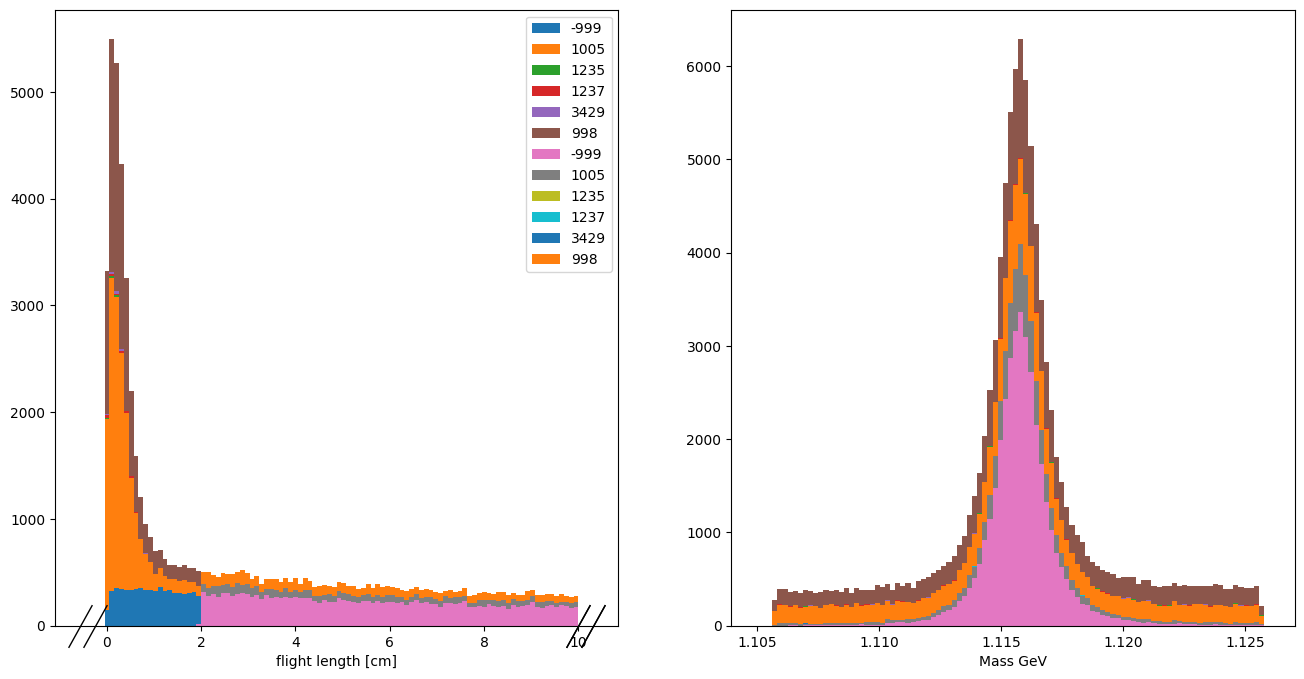

In [27]:
plt.figure(figsize=(16,8))

plt.subplot(1,2,1)
h_lambda_FL[:,:,'org'].stack('SP')[:].project('Lambda0FlightLen').plot(stack=True, histtype="fill")
h_lambda_FL[:,:,'fl_gt_val'].stack('SP')[:].project('Lambda0FlightLen').plot(stack=True, histtype="fill")

plt.legend()

plt.subplot(1,2,2)
h_lambda_mass[:,:,'org'].stack('SP')[:].project('Lambda0_unc_Mass').plot(stack=True, histtype="fill")
h_lambda_mass[:,:,'fl_gt_val'].stack('SP')[:].project('Lambda0_unc_Mass').plot(stack=True, histtype="fill")



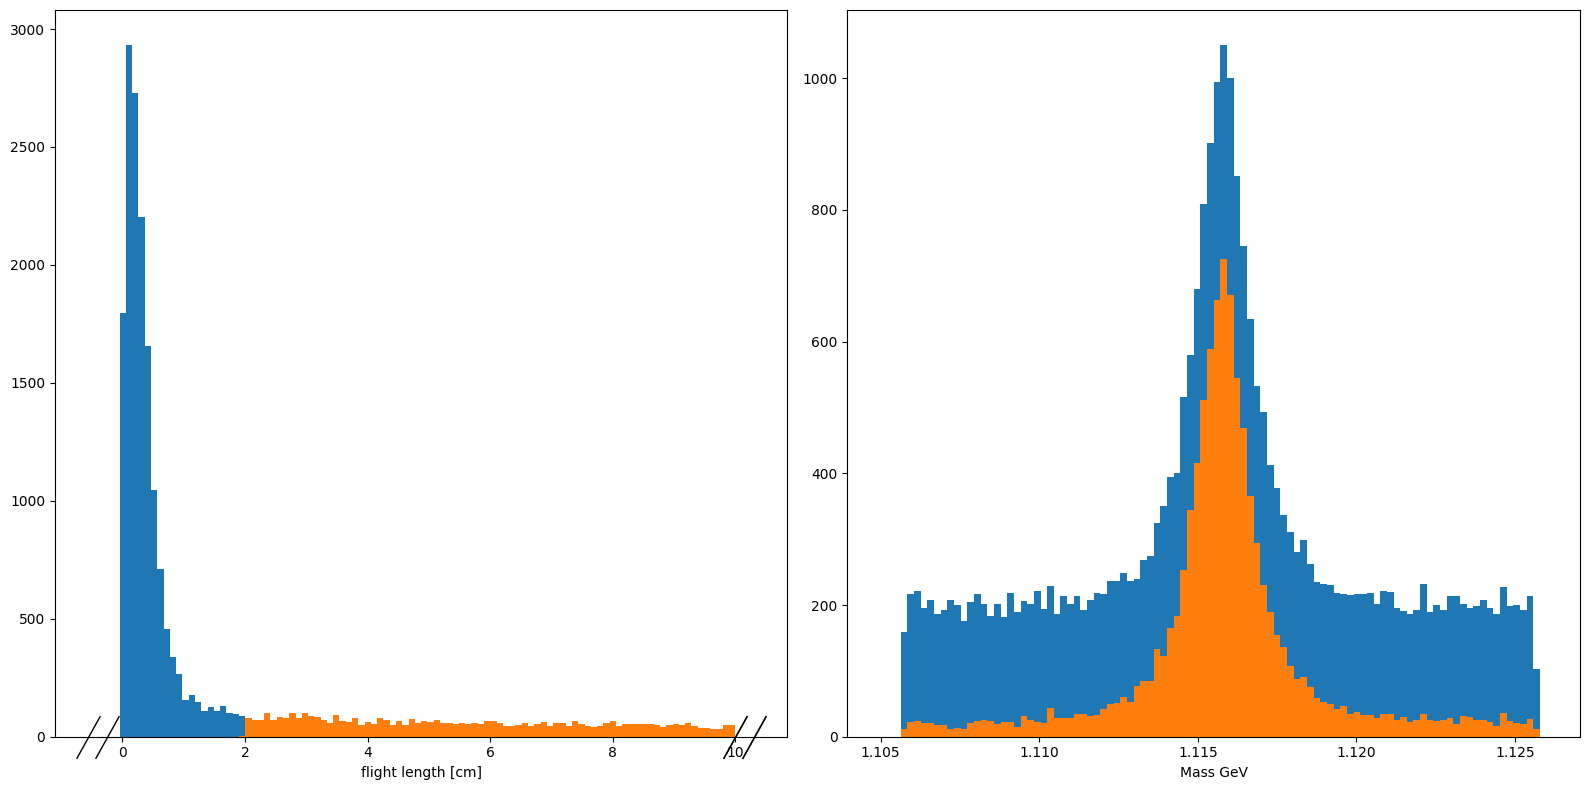

In [28]:
plt.figure(figsize=(16,8))

sp = '1005'

plt.subplot(1,2,1)
h_lambda_FL[:,sp,'org'].project('Lambda0FlightLen').plot(histtype="fill")
h_lambda_FL[:,sp,'fl_gt_val'].project('Lambda0FlightLen').plot(histtype="fill")

#plt.legend()

plt.subplot(1,2,2)
h_lambda_mass[:,sp,'org'].project('Lambda0_unc_Mass').plot(histtype="fill")
h_lambda_mass[:,sp,'fl_gt_val'].project('Lambda0_unc_Mass').plot(histtype="fill")

plt.tight_layout()

In [29]:
h_lambda_FL[:,:,'org']

Hist(
  Regular(100, -0.25, 10, name='Lambda0FlightLen', label='flight length [cm]'),
  StrCategory(['-999', '1005', '1235', '1237', '3429', '998'], growth=True, name='SP', label='sp modes'),
  storage=Weight()) # Sum: WeightedSum(value=63001, variance=63001) (WeightedSum(value=103658, variance=103658) with flow)

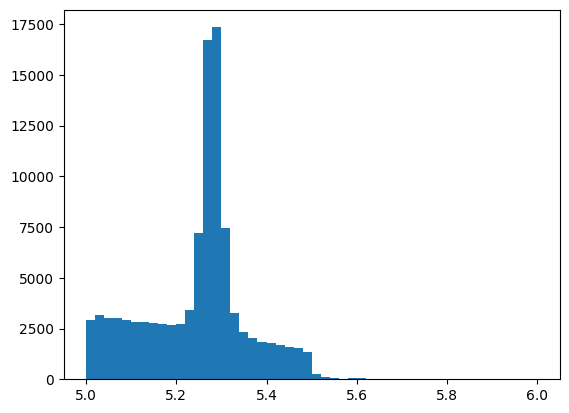

In [30]:
x= data["BMass"][:,0]

plt.hist(x, bins=50, range=(5,6));

# Next steps

* Plot `BpostFitMes` and `BpostFitDeltaE`
* Do individual histograms
* Do a 2D histogram (try with `Hist`)

